# Market Simulator — интерактивная симуляция

Notebook для удобного запуска и анализа симуляций рынка.

**Содержание**
1. Настройка и импорты
2. Параметры симуляции
3. Построение рынка и обзор
4. Запуск симуляции
5. Визуализация результатов
6. Дополнительный анализ
7. Сравнение стратегий
8. Интерактивный симулятор

## 1. Настройка и импорты

In [ ]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Гарантируем, что корень проекта в sys.path
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from market import (
    Market, Good, Seller,
    EpsilonGreedy, GradientAscent, REGISTRY,
    build_market,
)
from market.visualization import plot_simulation

# visualization.py при импорте вызывает matplotlib.use('Agg') —
# возвращаем inline-backend, чтобы plt.show() работал в notebook.
%matplotlib inline

print('Доступные стратегии:', list(REGISTRY))

## 2. Параметры симуляции

Меняйте значения ниже и перезапускайте последующие ячейки.

In [2]:
N_GOODS        = 2       # количество товаров (G1, G2, ...)
N_SELLERS      = 3       # количество начальных продавцов (S1, S2, ...)
BUYERS_PER_DAY = 1000    # размер потока покупателей
N_DAYS         = 90      # длительность симуляции (дней)
STRATEGY_NAME  = 'epsilon_greedy'   # 'epsilon_greedy' | 'gradient'
SEED           = 42      # фиксированный сид для воспроизводимости (None — случайно)

## 3. Построение рынка и обзор

Здесь видно: для каждого товара его себестоимость, скрытые параметры спроса (`value`, `lam`),
монопольную оптимальную цену и список продавцов.

In [3]:
market = build_market(N_GOODS, N_SELLERS, BUYERS_PER_DAY, SEED)

print(f"Рынок: {len(market.goods)} товара(ов), {len(market.sellers)} продавцов, "
      f"{market.buyers_per_day} покупателей/день\n")

print(f"{'Товар':<6} {'cost':>7} {'value':>7} {'lam':>6} {'opt':>7}   sellers")
print('-' * 60)
for gname, g in market.goods.items():
    carriers = [s.name for s in market.sellers if gname in s.goods]
    print(f"{gname:<6} {g.cost:>7.2f} {g.value:>7.2f} {g.lam:>6.3f} "
          f"{g.monopoly_optimal_price():>7.2f}   {carriers}")

print('\nАссортимент по продавцам:')
for s in market.sellers:
    print(f"  {s.name}: {s.goods}")

Рынок: 2 товара(ов), 3 продавцов, 1000 покупателей/день

Товар     cost   value    lam     opt   sellers
------------------------------------------------------------
G1       10.00   36.61  0.144   31.51   ['S1', 'S3']
G2       15.00   56.82  0.170   47.83   ['S1', 'S2', 'S3']

Ассортимент по продавцам:
  S1: ['G1', 'G2']
  S2: ['G2']
  S3: ['G1', 'G2']


## 5. Запуск симуляции

`verbose=False` отключает периодический лог по дням. Поставьте `True`, если хотите
видеть промежуточный вывод (~10 точек на симуляцию).

In [5]:
strategy = REGISTRY[STRATEGY_NAME]
market.run(n_days=N_DAYS, strategy=strategy, verbose=False)

print(f"Симуляция завершена ({market.day} дней, стратегия={STRATEGY_NAME}).\n")
print('Итоговая накопленная прибыль:')
for s in sorted(market.sellers, key=lambda x: -x.total_profit()):
    print(f"  {s.name:<8}  {s.total_profit():>10.1f}")

Симуляция завершена (90 дней, стратегия=epsilon_greedy).

Итоговая накопленная прибыль:
  S1          380236.1
  S3          377194.7
  S2          124551.3


## 6. Визуализация результатов

`plot_simulation` сохраняет PNG (бэкенд `Agg`); ниже отображаем её прямо в notebook.


Plot saved → market_simulation.png


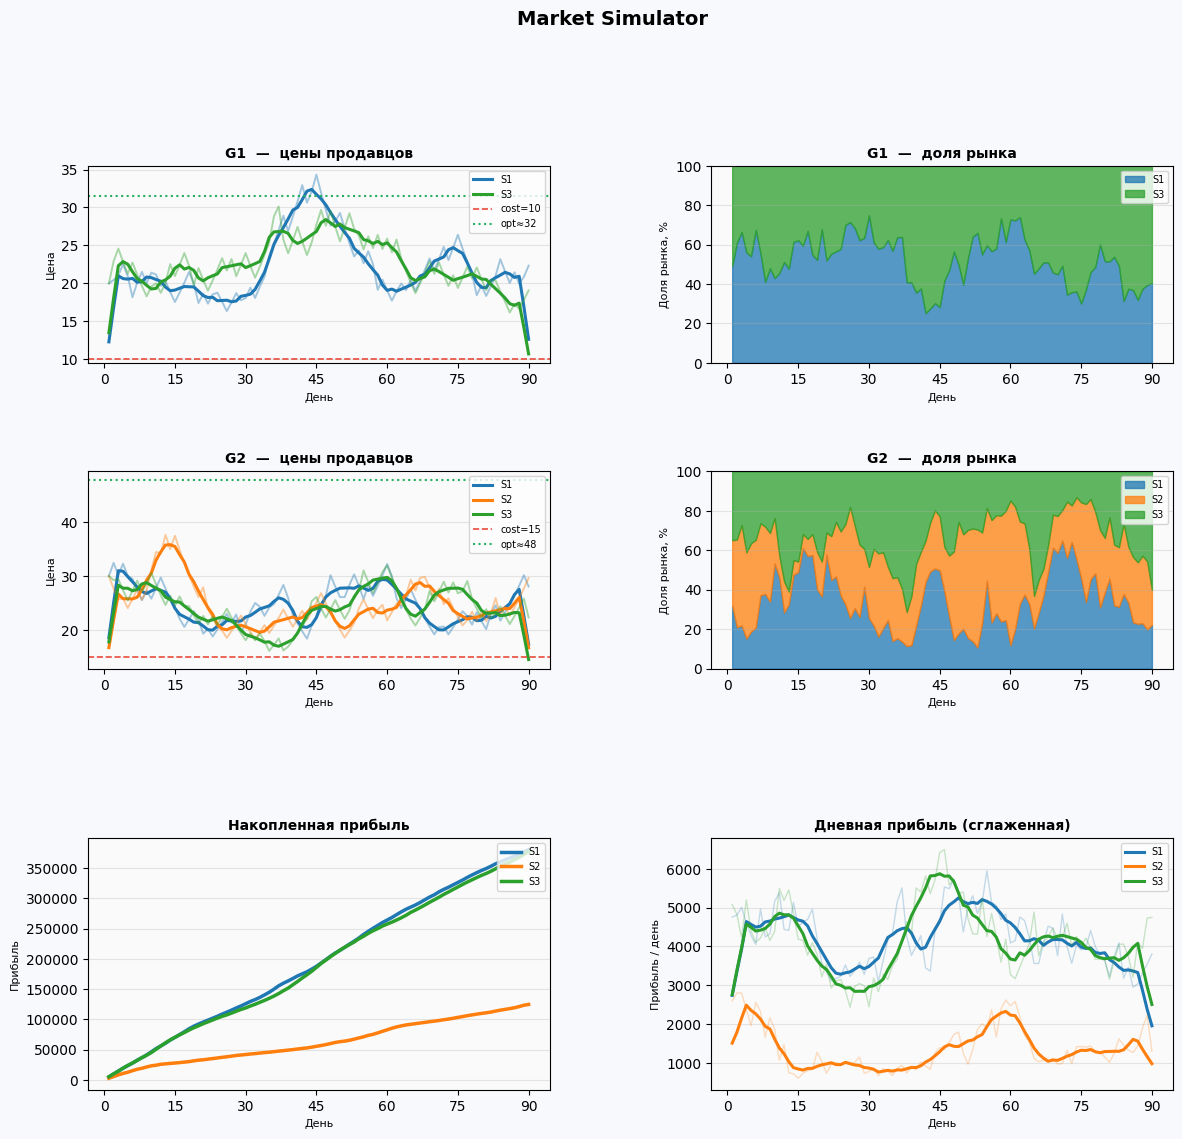

In [6]:
plot_path = 'market_simulation.png'
plot_simulation(market, save_path=plot_path)
# display(Image(filename=plot_path))

## 7. Дополнительный анализ

### 7.1 Накопленная прибыль (inline)

Гибкий inline-график в стиле notebook (без сохранения в файл).

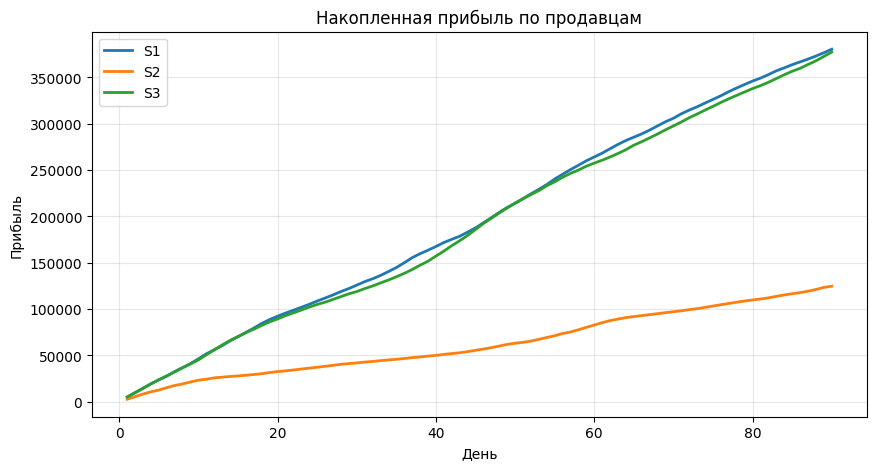

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
days = np.arange(1, market.day + 1)
for s in market.sellers:
    ax.plot(days, np.cumsum(s.profit_series(market.day)), label=s.name, linewidth=2)
ax.set_title('Накопленная прибыль по продавцам')
ax.set_xlabel('День')
ax.set_ylabel('Прибыль')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### 7.2 Сходимость цены к монопольному оптимуму

In [ ]:
good_names = market.goods.names()
fig, axes = plt.subplots(len(good_names), 1, figsize=(10, 3.5 * len(good_names)),
                         squeeze=False)

for row, gname in enumerate(good_names):
    ax   = axes[row, 0]
    good = market.goods[gname]
    for s in market.sellers:
        if gname not in s.goods:
            continue
        prices = s.hist_price[gname]
        s_days = np.arange(s.start_day, s.start_day + len(prices))
        ax.plot(s_days, prices, label=s.name, alpha=0.85, linewidth=1.6)
    ax.axhline(good.cost, color='red', linestyle='--', label=f'cost={good.cost:.1f}')
    ax.axhline(good.monopoly_optimal_price(), color='green', linestyle=':',
               label=f'opt≈{good.monopoly_optimal_price():.1f}')
    ax.set_title(f'{gname} — цены продавцов')
    ax.set_xlabel('День')
    ax.set_ylabel('Цена')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7.3 Финальная цена vs. оптимум

In [9]:
rows = []
for gname, good in market.goods.items():
    opt = good.monopoly_optimal_price()
    for s in market.sellers:
        if gname not in s.goods or not s.hist_price[gname]:
            continue
        last  = s.hist_price[gname][-1]
        delta = (last - opt) / opt * 100
        rows.append((gname, s.name, good.cost, last, opt, delta))

print(f"{'good':<5} {'seller':<8} {'cost':>7} {'final':>7} {'opt':>7} {'Δ%':>7}")
print('-' * 50)
for gname, sname, cost, last, opt, delta in rows:
    print(f"{gname:<5} {sname:<8} {cost:>7.2f} {last:>7.2f} {opt:>7.2f} {delta:>+6.1f}%")

good  seller      cost   final     opt      Δ%
--------------------------------------------------
G1    S1         10.00   22.33   31.51  -29.1%
G1    S3         10.00   19.08   31.51  -39.4%
G2    S1         15.00   28.05   47.83  -41.3%
G2    S2         15.00   29.63   47.83  -38.1%
G2    S3         15.00   22.28   47.83  -53.4%


## 8. Сравнение стратегий

Прогон одной и той же конфигурации рынка под каждой стратегией из реестра.
Сравниваем суммарную прибыль рынка.

In [ ]:
def run_with(strategy_name: str, n_days: int = N_DAYS) -> Market:
    m = build_market(N_GOODS, N_SELLERS, BUYERS_PER_DAY, SEED)
    m.run(n_days=n_days, strategy=REGISTRY[strategy_name], verbose=False)
    return m

results = {name: run_with(name) for name in REGISTRY}

fig, ax = plt.subplots(figsize=(10, 5))
for name, m in results.items():
    total = np.zeros(m.day)
    for s in m.sellers:
        total += s.profit_series(m.day)
    ax.plot(np.arange(1, m.day + 1), np.cumsum(total),
            label=f"{name}  (Σ={total.sum():.0f})", linewidth=2)
ax.set_title('Суммарная прибыль рынка по стратегиям')
ax.set_xlabel('День')
ax.set_ylabel('Накопленная прибыль (все продавцы)')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 9. Интерактивный симулятор

Управляй рынком через виджеты:
- **Настройка** — число товаров/продавцов/покупателей, стратегия, сид
- **Управление** — шаг +1, +10 или произвольное число дней
- **Метрики и графики** — обновляются после каждого шага в реальном времени

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import numpy as np, sys
from pathlib import Path

_root = str(Path.cwd())
if _root not in sys.path:
    sys.path.insert(0, _root)

from market import build_market, REGISTRY

# ── shared state ──────────────────────────────────────────────────
_st = {'market': None, 'strategy': None}

# ── helpers ───────────────────────────────────────────────────────
def _step(n: int):
    m, s = _st['market'], _st['strategy']
    for _ in range(n):
        m._simulate_day()
        m._update_prices(s)

def _smooth(arr, days, w: int):
    arr = np.asarray(arr, dtype=float)
    if len(arr) < w:
        return days, arr
    sm     = np.convolve(arr, np.ones(w) / w, mode='valid')
    offset = (w - 1) // 2
    return days[offset: offset + len(sm)], sm

def _metrics_html(m) -> str:
    th = '<th style="padding:3px 10px;border-bottom:1px solid #ccc;text-align:left">'
    rows = []
    for s in sorted(m.sellers, key=lambda x: -x.total_profit()):
        p_day = sum((s.hist_profit[g][-1] if s.hist_profit[g] else 0) for g in s.goods)
        s_day = sum((s.hist_sales[g][-1]  if s.hist_sales[g]  else 0) for g in s.goods)
        prices  = '  '.join(f'{g}: <b>{s.prices[g]:.1f}</b>' for g in s.goods)
        opt_gap = '  '.join(
            f'{g}: {(s.prices[g]/m.goods[g].monopoly_optimal_price()-1)*100:+.0f}%'
            for g in s.goods
        )
        rows.append(
            f'<tr><td><b>{s.name}</b></td>'
            f'<td>{s.total_profit():,.0f}</td>'
            f'<td>{p_day:,.0f}</td>'
            f'<td>{s_day}</td>'
            f'<td style="font-family:monospace;font-size:11px">{prices}</td>'
            f'<td style="font-family:monospace;font-size:11px;color:#888">{opt_gap}</td></tr>'
        )
    return (
        f'<h4 style="margin:6px 0">📅 День {m.day}</h4>'
        f'<table style="border-collapse:collapse;font-size:12px">'
        f'<thead><tr style="background:#f0f0f0">'
        f'{th}Продавец</th>{th}Прибыль Σ</th>{th}Сегодня</th>'
        f'{th}Продаж</th>{th}Цены</th>{th}vs opt</th></tr></thead>'
        f'<tbody>{"".join(rows)}</tbody></table>'
    )

def _redraw(m):
    n = m.day
    if n == 0:
        return
    days    = np.arange(1, n + 1)
    gnames  = m.goods.names()
    palette = plt.cm.tab10.colors
    sc      = {s.name: palette[i % 10] for i, s in enumerate(m.sellers)}
    n_rows  = len(gnames) + 1

    fig = plt.figure(figsize=(12, 3.5 * n_rows))
    fig.patch.set_facecolor('#F7F9FC')
    gs  = gridspec.GridSpec(n_rows, 2, hspace=0.52, wspace=0.32)

    for row, gname in enumerate(gnames):
        good     = m.goods[gname]
        carriers = [s for s in m.sellers if gname in s.goods]
        opt      = good.monopoly_optimal_price()

        ax = fig.add_subplot(gs[row, 0])
        ax.set_facecolor('#FAFAFA')
        for s in carriers:
            ph = s.hist_price[gname]
            if not ph:
                continue
            sd = np.arange(s.start_day, s.start_day + len(ph))
            ax.plot(sd, ph, color=sc[s.name], alpha=0.28, lw=1)
            sd_sm, sm = _smooth(ph, sd, w=5)
            ax.plot(sd_sm, sm, color=sc[s.name], lw=2, label=s.name)
        ax.axhline(good.cost, color='#E74C3C', ls='--', lw=1.2, label=f'cost={good.cost:.0f}')
        ax.axhline(opt,       color='#27AE60', ls=':',  lw=1.5, label=f'opt≈{opt:.0f}')
        ax.set_title(f'{gname} — цены', fontsize=9, fontweight='bold')
        ax.set_xlabel('День', fontsize=8); ax.set_ylabel('Цена', fontsize=8)
        ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.25)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))

        ax2 = fig.add_subplot(gs[row, 1])
        ax2.set_facecolor('#FAFAFA')
        sm_arr = np.array([s.sales_series(gname, n) for s in carriers])
        tots   = sm_arr.sum(axis=0)
        shares = sm_arr / np.where(tots == 0, 1, tots) * 100
        bot    = np.zeros(n)
        for idx, s in enumerate(carriers):
            ax2.fill_between(days, bot, bot + shares[idx],
                             color=sc[s.name], alpha=0.75, label=s.name)
            bot += shares[idx]
        ax2.set_ylim(0, 100)
        ax2.set_title(f'{gname} — доля рынка', fontsize=9, fontweight='bold')
        ax2.set_xlabel('День', fontsize=8); ax2.set_ylabel('%', fontsize=8)
        ax2.legend(fontsize=7, loc='upper right'); ax2.grid(alpha=0.2)
        ax2.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))

    ax3 = fig.add_subplot(gs[n_rows-1, 0])
    ax3.set_facecolor('#FAFAFA')
    for s in m.sellers:
        ax3.plot(days, np.cumsum(s.profit_series(n)),
                 color=sc[s.name], lw=2, label=s.name)
    ax3.set_title('Накопленная прибыль', fontsize=9, fontweight='bold')
    ax3.set_xlabel('День', fontsize=8); ax3.set_ylabel('Прибыль', fontsize=8)
    ax3.legend(fontsize=7); ax3.grid(alpha=0.25)
    ax3.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))

    ax4 = fig.add_subplot(gs[n_rows-1, 1])
    ax4.set_facecolor('#FAFAFA')
    for s in m.sellers:
        daily = s.profit_series(n)
        d_sm, sm_d = _smooth(daily, days, w=7)
        ax4.plot(days, daily, color=sc[s.name], alpha=0.2, lw=1)
        ax4.plot(d_sm, sm_d,  color=sc[s.name], lw=2, label=s.name)
    ax4.set_title('Дневная прибыль (сглаж.)', fontsize=9, fontweight='bold')
    ax4.set_xlabel('День', fontsize=8); ax4.set_ylabel('Прибыль/день', fontsize=8)
    ax4.legend(fontsize=7); ax4.grid(alpha=0.25)
    ax4.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def _refresh():
    m = _st['market']
    if m is None:
        return
    with out_metrics:
        clear_output(wait=True)
        display(HTML(_metrics_html(m)))
    with out_charts:
        clear_output(wait=True)
        _redraw(m)

def _set_controls(enabled: bool):
    for w in (btn_step1, btn_step10, btn_run, btn_reset):
        w.disabled = not enabled

_W = widgets.Layout
_S = lambda w: {'description_width': w}

w_goods   = widgets.BoundedIntText(value=2, min=1, max=8,  description='Товаров:',    style=_S('75px'), layout=_W(width='155px'))
w_sellers = widgets.BoundedIntText(value=3, min=1, max=10, description='Продавцов:',  style=_S('75px'), layout=_W(width='165px'))
w_buyers  = widgets.BoundedIntText(value=1000, min=100, max=20000, step=100,
                                   description='Покупателей:', style=_S('85px'), layout=_W(width='185px'))
w_seed    = widgets.BoundedIntText(value=42, min=0, max=99999, description='Сид:', style=_S('35px'), layout=_W(width='130px'))
w_strat   = widgets.Dropdown(options=list(REGISTRY), description='Стратегия:', style=_S('75px'), layout=_W(width='225px'))
btn_init  = widgets.Button(description='⚙ Инициализировать', button_style='primary', layout=_W(width='185px'))
out_setup = widgets.Output()

btn_step1  = widgets.Button(description='+1 день',   button_style='success', disabled=True, layout=_W(width='105px'))
btn_step10 = widgets.Button(description='+10 дней',  button_style='success', disabled=True, layout=_W(width='105px'))
w_run_n    = widgets.BoundedIntText(value=30, min=1, max=9999, description='Дней:', style=_S('42px'), layout=_W(width='125px'))
btn_run    = widgets.Button(description='▶ Запустить', button_style='success', disabled=True, layout=_W(width='125px'))
btn_reset  = widgets.Button(description='↺ Сброс',   button_style='danger',  disabled=True, layout=_W(width='95px'))

out_metrics = widgets.Output()
out_charts  = widgets.Output()

def _on_init(_b):
    m = build_market(w_goods.value, w_sellers.value, w_buyers.value, w_seed.value)
    _st['market']   = m
    _st['strategy'] = REGISTRY[w_strat.value]
    with out_setup:
        clear_output(wait=True)
        lines = []
        for gname, g in m.goods.items():
            carriers = [s.name for s in m.sellers if gname in s.goods]
            lines.append(
                f'<b>{gname}</b>: cost={g.cost:.1f} | value={g.value:.1f} | '
                f'lam={g.lam:.3f} | opt≈{g.monopoly_optimal_price():.1f} | '
                f'продавцы: {carriers}'
            )
        display(HTML('<br>'.join(lines)))
    _set_controls(True)
    _refresh()

def _on_step1(_b):  _step(1);             _refresh()
def _on_step10(_b): _step(10);            _refresh()
def _on_run(_b):    _step(w_run_n.value); _refresh()

def _on_reset(_b):
    _st['market'] = _st['strategy'] = None
    for o in (out_setup, out_metrics, out_charts):
        with o: clear_output(wait=True)
    _set_controls(False)

btn_init.on_click(_on_init)
btn_step1.on_click(_on_step1)
btn_step10.on_click(_on_step10)
btn_run.on_click(_on_run)
btn_reset.on_click(_on_reset)

sep = lambda: widgets.HTML('<hr style="margin:8px 0;border-color:#ddd">')
display(widgets.VBox([
    widgets.HTML('<h3 style="margin:6px 0">⚙ Настройка рынка</h3>'),
    widgets.HBox([w_goods, w_sellers, w_buyers, w_seed]),
    widgets.HBox([w_strat, btn_init]),
    out_setup,
    sep(),
    widgets.HTML('<h3 style="margin:6px 0">▶ Управление</h3>'),
    widgets.HBox([btn_step1, btn_step10, w_run_n, btn_run, btn_reset]),
    sep(),
    widgets.HTML('<h3 style="margin:6px 0">📊 Метрики</h3>'),
    out_metrics,
    out_charts,
]))